In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# ========== PREPROCESSING OF DATASET ============
"""
Preprocess MRI-to-CT dataset on Kaggle.
Reads patient folders under /Task1/brain,
checks for .nii files (mr.nii, ct.nii, mask.nii),
and builds a list of patient records.
"""

import gzip
import shutil
from pathlib import Path
from tqdm import tqdm

# --- 1. Configuration ---
# Base path to the extracted dataset folder (brain anatomy only)
EXTRACT_PATH = Path("/kaggle/input/mri-to-ct-project/Task1/brain")

# --- 2. Find all patient directories ---
print(f"\n--> Searching for patient directories in {EXTRACT_PATH}")
patient_dirs = [p for p in EXTRACT_PATH.iterdir() if p.is_dir()]

all_patients_data = []

# --- 3. Process patient data ---
print("\n--> Finding patient scans and decompressing .nii.gz if any...")

for patient_dir in tqdm(patient_dirs, desc="Processing Patients"):
    mr_gz_path = patient_dir / 'mr.nii.gz'
    ct_gz_path = patient_dir / 'ct.nii.gz'

    mr_path = patient_dir / 'mr.nii'
    ct_path = patient_dir / 'ct.nii'
    mask_path = patient_dir / 'mask.nii'

    # Decompress mr.nii.gz to mr.nii if needed
    if mr_gz_path.exists() and not mr_path.exists():
        with gzip.open(mr_gz_path, 'rb') as f_in, open(mr_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

    # Decompress ct.nii.gz to ct.nii if needed
    if ct_gz_path.exists() and not ct_path.exists():
        with gzip.open(ct_gz_path, 'rb') as f_in, open(ct_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

    # Collect patient record if files exist
    record = {
        'id': patient_dir.name,
        'path': str(patient_dir),
        'mr_path': str(mr_path) if mr_path.exists() else None,
        'ct_path': str(ct_path) if ct_path.exists() else None,
        'mask_path': str(mask_path) if mask_path.exists() else None,
        'anatomy': 'brain',  # Update if adding pelvis or others
    }

    all_patients_data.append(record)

# --- 4. Final summary ---
print("\n" + "="*50)
print("Preprocessing complete!")
print(f"Total patient records found: {len(all_patients_data)}")
if all_patients_data:
    print("\nExample patient record:")
    print(all_patients_data[0])
print("="*50)



--> Searching for patient directories in /kaggle/input/mri-to-ct-project/Task1/brain

--> Finding patient scans and decompressing .nii.gz if any...


Processing Patients: 100%|██████████| 181/181 [00:02<00:00, 75.08it/s]


Preprocessing complete!
Total patient records found: 181

Example patient record:
{'id': '1BC090', 'path': '/kaggle/input/mri-to-ct-project/Task1/brain/1BC090', 'mr_path': '/kaggle/input/mri-to-ct-project/Task1/brain/1BC090/mr.nii', 'ct_path': '/kaggle/input/mri-to-ct-project/Task1/brain/1BC090/ct.nii', 'mask_path': '/kaggle/input/mri-to-ct-project/Task1/brain/1BC090/mask.nii', 'anatomy': 'brain'}


In [ ]:
# ============================= BRAIN SLICING =======================================
import nibabel as nib
import numpy as np
from pathlib import Path
from tqdm import tqdm
import shutil
import re
import os

# --- 1. Configuration ---
INPUT_DATA_PATH = Path('/kaggle/input/mri-to-ct-project/Task1/brain')
OUTPUT_SLICES_PATH = Path('/kaggle/working/processed_slices_npy')
HU_MIN, HU_MAX = -1000.0, 2000.0

# --- Cleanup and Directory Creation ---
if OUTPUT_SLICES_PATH.exists():
    print("--> Removing old processed slices directory...")
    shutil.rmtree(OUTPUT_SLICES_PATH)
PATH_TRAIN_A = OUTPUT_SLICES_PATH / 'trainA'  # MRI
PATH_TRAIN_B = OUTPUT_SLICES_PATH / 'trainB'  # CT
PATH_TRAIN_A.mkdir(parents=True, exist_ok=True)
PATH_TRAIN_B.mkdir(parents=True, exist_ok=True)
print(f"Output directories created at {OUTPUT_SLICES_PATH}")

# --- 2. Helper Functions ---
def sanitize_filename(name):
    return re.sub(r'[^a-zA-Z0-9_-]', '_', name)

def normalize_mri(mri_data):
    lower_bound, upper_bound = np.percentile(mri_data, [0.5, 99.5])
    clipped_data = np.clip(mri_data, lower_bound, upper_bound)
    normalized = (clipped_data - lower_bound) / (upper_bound - lower_bound + 1e-6)
    return 2 * normalized - 1

def normalize_ct(ct_data):
    clipped_data = np.clip(ct_data, HU_MIN, HU_MAX)
    normalized = (clipped_data - HU_MIN) / (HU_MAX - HU_MIN + 1e-6)
    return 2 * normalized - 1

# NEW: Helper to focus on the central part of the scan
def get_middle_slice_range(total_slices, coverage=0.6):
    """
    Calculates the start and end index to cover the central portion of the scan.
    coverage=0.8 means we process the middle 80% of slices.
    """
    start = int(total_slices * (1 - coverage) / 2)
    end = int(total_slices * (1 + coverage) / 2)
    return start, end

# UPDATED: The filtering function is now more robust
def is_useful_slice(mri_slice, ct_slice, tissue_ratio=0.3, std_threshold=0.06):
    """
    Checks if a slice is useful based on tissue content and intensity variance.
    - tissue_ratio: Minimum percentage of non-background pixels.
    - std_threshold: Minimum standard deviation of pixel values in the MRI slice.
    """
    # Check 1: Ensure there's enough tissue
    mri_tissue = np.sum(mri_slice > -0.9) / mri_slice.size
    ct_tissue = np.sum(ct_slice > -0.9) / ct_slice.size
    if mri_tissue < tissue_ratio or ct_tissue < tissue_ratio:
        return False
        
    # Check 2: Ensure there's enough anatomical detail (variance) in the MRI
    if mri_slice.std() < std_threshold:
        return False
        
    return True

# --- 3. Main Processing Logic ---
print("\n--> Starting enhanced 3D to 2D slice conversion (saving as .npy)...")
patient_dirs = [p for p in INPUT_DATA_PATH.iterdir() if p.is_dir()]
slices_saved_count = 0
total_slices_examined = 0

for patient_dir in tqdm(patient_dirs, desc="Processing Volumes"):
    try:
        mri_path = patient_dir / 'mr.nii'
        ct_path = patient_dir / 'ct.nii'

        if not (mri_path.exists() and ct_path.exists()):
            continue

        mri_vol = nib.load(mri_path).get_fdata().astype(np.float32)
        ct_vol = nib.load(ct_path).get_fdata().astype(np.float32)

        num_slices = min(mri_vol.shape[2], ct_vol.shape[2])
        
        # UPDATED: Only iterate through the middle slices of the volume
        start_idx, end_idx = get_middle_slice_range(num_slices, coverage=0.8)

        for i in range(start_idx, end_idx):
            total_slices_examined += 1
            mri_slice_raw = mri_vol[:, :, i]
            ct_slice_raw = ct_vol[:, :, i]

            mri_slice_norm = normalize_mri(mri_slice_raw)
            ct_slice_norm = normalize_ct(ct_slice_raw)

            # UPDATED: Use the more robust filtering function
            if is_useful_slice(mri_slice_norm, ct_slice_norm):
                patient_id = sanitize_filename(patient_dir.name)
                filename = f"{patient_id}_slice_{i:03d}.npy"

                np.save(PATH_TRAIN_A / filename, mri_slice_norm)
                np.save(PATH_TRAIN_B / filename, ct_slice_norm)
                slices_saved_count += 1
                
    except Exception as e:
        print(f"Error processing {patient_dir.name}: {e}")

# --- 4. Final Report ---
print("\n" + "="*50)
print("✅ Processing complete!")
print(f"Total slices examined (within middle 60%): {total_slices_examined}")
print(f"Total useful slices saved: {slices_saved_count}")
if total_slices_examined > 0:
    selection_ratio = (slices_saved_count / total_slices_examined) * 100
    print(f"Selection Ratio: {selection_ratio:.2f}% of examined slices were saved.")
print("="*50)

Output directories created at /kaggle/working/processed_slices_npy

--> Starting enhanced 3D to 2D slice conversion (saving as .npy)...


Processing Volumes: 100%|██████████| 181/181 [04:22<00:00,  1.45s/it]


✅ Processing complete!
Total slices examined (within middle 60%): 27675
Total useful slices saved: 21183
Selection Ratio: 76.54% of examined slices were saved.


In [ ]:
# ==============================  PATIENT LEVEL SPLITING =================================
import re
import shutil
import random
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict


# --- 0. Auto-detect Source and Destination Paths ---
CANDIDATES = [
    Path("/kaggle/working/processed_slices_npy"),  # Kaggle
    Path("/content/processed_slices_npy"),        # Colab
    Path("./processed_slices_npy"),               # Local
]
SOURCE_ROOT = next((p for p in CANDIDATES if p.exists()), None)
if SOURCE_ROOT is None:
    raise FileNotFoundError(f"Source data not found in: {CANDIDATES}.")

SRC_A = SOURCE_ROOT / "trainA"  # MRI
SRC_B = SOURCE_ROOT / "trainB"  # CT
DEST_ROOT = Path("/kaggle/working/paired_slices_split_npy")
DEST_SPLITS = ["train", "val", "test"]

# --- 1. Configuration ---
# This is the key change to ensure files are copied, preventing broken link errors.
USE_SYMLINKS = False
SEED = 42
RATIOS = (0.70, 0.15, 0.15) # train, val, test

# --- 2. Helper Functions ---
def patient_id_from_name(name: str) -> str:
    """Extract patient ID from filename (e.g., 'PATIENTID_slice_123.npy')."""
    m = re.match(r"^(.+?)_slice_\d+\.npy$", name, re.IGNORECASE)
    return m.group(1) if m else name.split("_slice_")[0]

def make_dirs():
    """Create the train/val/test directory structure."""
    if DEST_ROOT.exists():
        print(f"Removing old destination directory: {DEST_ROOT}")
        shutil.rmtree(DEST_ROOT)
    for split in DEST_SPLITS:
        for sub in ["A", "B"]:
            (DEST_ROOT / split / sub).mkdir(parents=True, exist_ok=True)
    print(f"Created new directory structure at: {DEST_ROOT}")

def link_or_copy(src: Path, dst: Path, use_symlink=False):
    """Copies or symlinks a file from source to destination."""
    if dst.exists(): return
    if use_symlink:
        dst.symlink_to(src.resolve())
    else:
        shutil.copy2(src, dst)

def compute_split_counts(n: int, ratios: tuple) -> tuple[int,int,int]:
    """Robustly compute train, val, and test counts from patient total."""
    tr, va, _ = ratios
    n_train = int(round(tr * n))
    n_val   = int(round(va * n))
    n_test  = n - n_train - n_val
    # Ensure test set isn't empty if we have enough patients
    if n >= 3 and n_test <= 0:
        n_val -= 1
        n_test = 1
    return n_train, n_val, n_test

# --- 3. Index All Slices by Patient ID ---
print(f"Indexing files from: {SOURCE_ROOT}")
a_files = sorted(SRC_A.glob("*.npy"))
b_index = {p.name: p for p in sorted(SRC_B.glob("*.npy"))}

patients = defaultdict(list)
for a_file in a_files:
    if a_file.name in b_index:
        pid = patient_id_from_name(a_file.name)
        patients[pid].append(a_file.name)

unique_patients = sorted(patients.keys())
if not unique_patients:
    raise RuntimeError(f"No patient slices found in {SRC_A}. Please run the preprocessing script first.")

# --- 4. Split Patients into Sets ---
random.Random(SEED).shuffle(unique_patients)
n = len(unique_patients)
n_train, n_val, n_test = compute_split_counts(n, RATIOS)

train_p = set(unique_patients[:n_train])
val_p   = set(unique_patients[n_train : n_train + n_val])
test_p  = set(unique_patients[n_train + n_val :])

# --- 5. Create Split Directories and Copy Files ---
make_dirs()
counts = {"train": defaultdict(int), "val": defaultdict(int), "test": defaultdict(int)}

print("Copying files into respective splits...")
# Added tqdm progress bar here
for pid, slice_names in tqdm(patients.items(), desc="Splitting Patients"):
    split = "train" if pid in train_p else "val" if pid in val_p else "test"
    counts[split]["patients"] += 1
    for name in slice_names:
        link_or_copy(SRC_A / name, DEST_ROOT / split / "A" / name, USE_SYMLINKS)
        link_or_copy(b_index[name], DEST_ROOT / split / "B" / name, USE_SYMLINKS)
        counts[split]["slices"] += 1

# --- 6. Final Report ---
print("\n" + "="*55)
print("✅ Patient-level split complete (Files Copied)")
print("="*55)
print(f"SOURCE: {SOURCE_ROOT}")
print(f"DESTINATION: {DEST_ROOT}")
print(f"Total Unique Patients: {n}")
print("-" * 25)
print(f"  Train : {counts['train']['patients']} patients, {counts['train']['slices']} slices")
print(f"  Val   : {counts['val']['patients']} patients, {counts['val']['slices']} slices")
print(f"  Test  : {counts['test']['patients']} patients, {counts['test']['slices']} slices")
print("="*55)

Indexing files from: /kaggle/working/processed_slices_npy
Created new directory structure at: /kaggle/working/paired_slices_split_npy
Copying files into respective splits...


Splitting Patients: 100%|██████████| 180/180 [00:39<00:00,  4.61it/s]


✅ Patient-level split complete (Files Copied)
SOURCE: /kaggle/working/processed_slices_npy
DESTINATION: /kaggle/working/paired_slices_split_npy
Total Unique Patients: 180
-------------------------
  Train : 126 patients, 14799 slices
  Val   : 27 patients, 3264 slices
  Test  : 27 patients, 3120 slices


🔬 1. Checking Patient-Level Split Integrity...
  Train patients: 126
  Val patients:   27
  Test patients:  27
-------------------------
  Overlap Train–Val:  0
  Overlap Train–Test: 0
  Overlap Val–Test:   0
✅ Integrity check passed. No patient overlap between splits.

📊 2. Calculating Per-Split Statistics...
(Stats are based on normalized [-1, 1] data from a random sample)
  - TRAIN | Pairs: 14799  | MRI (mean≈-0.63, std≈0.51) | CT (mean≈-0.68, std≈0.40)
  - VAL   | Pairs: 3264   | MRI (mean≈-0.62, std≈0.52) | CT (mean≈-0.67, std≈0.40)
  - TEST  | Pairs: 3120   | MRI (mean≈-0.63, std≈0.52) | CT (mean≈-0.68, std≈0.40)

🖼️ 3. Generating Visual Analysis (one sample per split)...


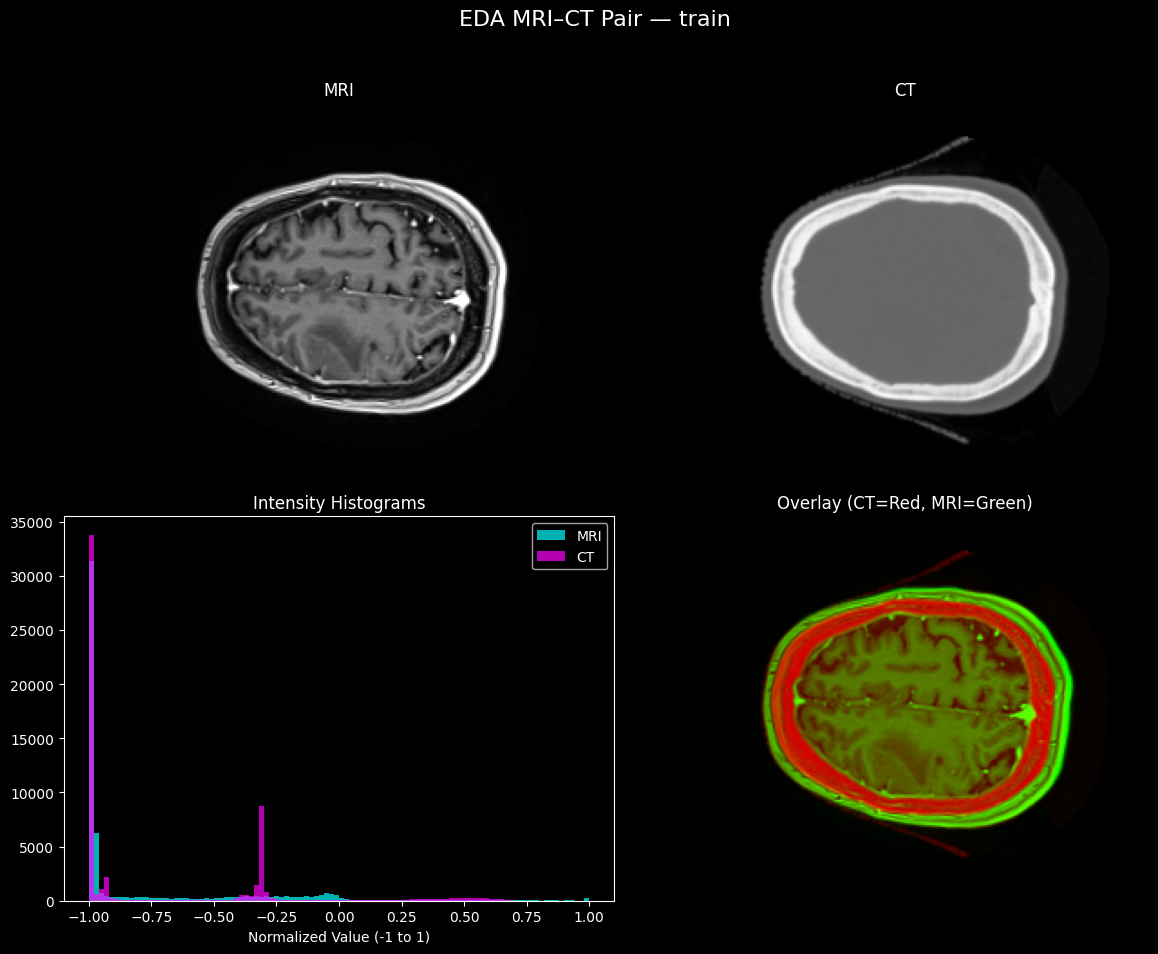

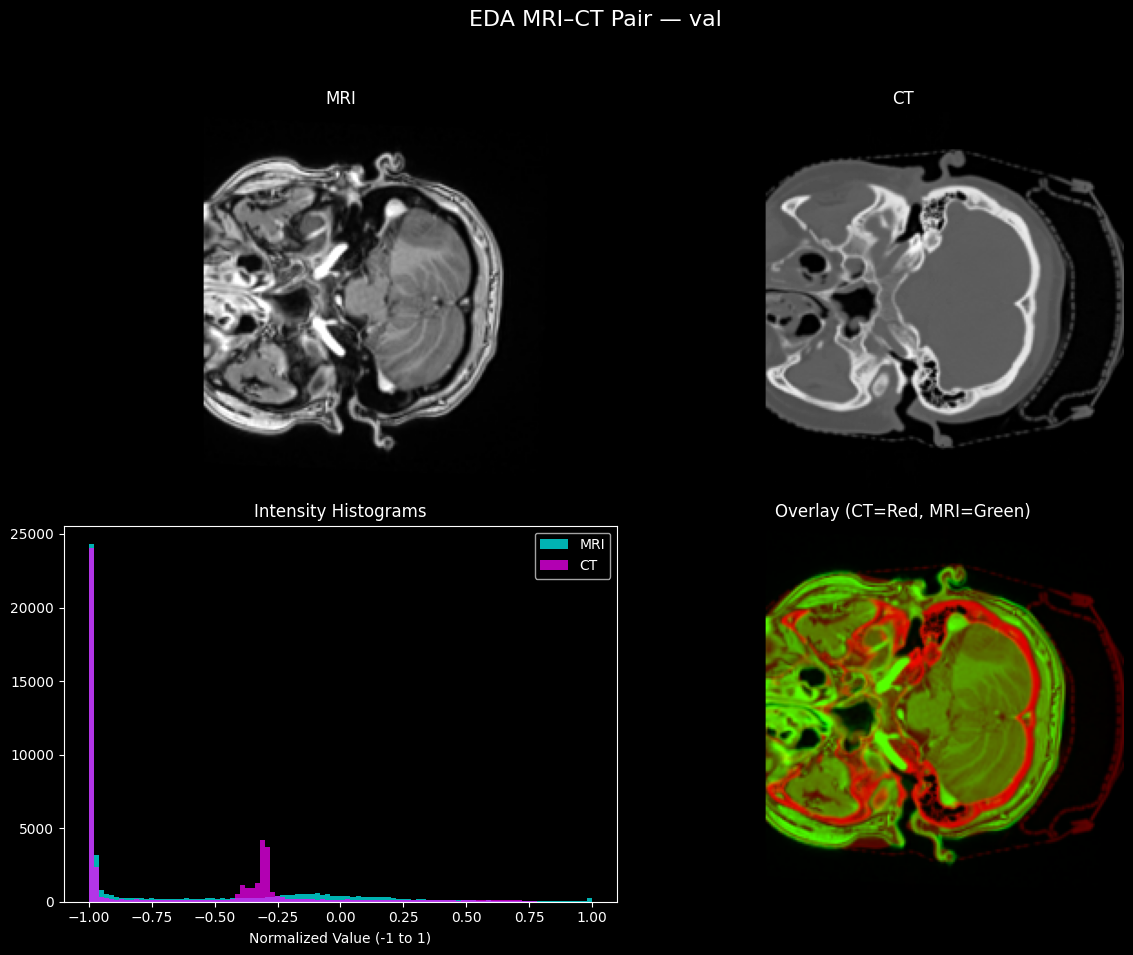

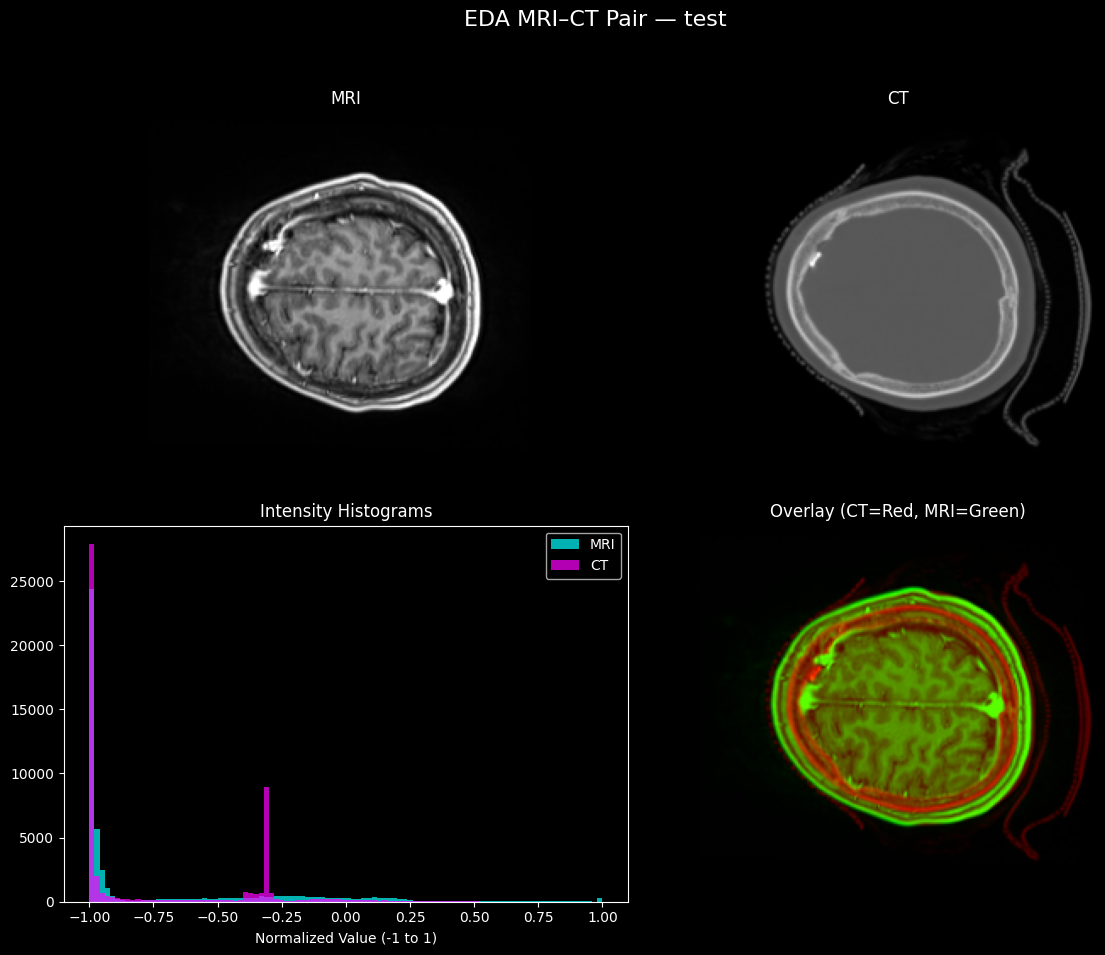

In [ ]:
# ==================================== EXPLOTARY DATA ANALYSIS ===========================================================
#
# HOW TO USE:
# 1. First, run the `1_enhanced_slicing...` script to create the `processed_slices_npy` folder.
# 2. Next, run the data splitting script with `USE_SYMLINKS = False` to create the `paired_slices_split_npy` folder.
# 3. Finally, run this script to analyze the split data.
#

from pathlib import Path
from collections import defaultdict
import re
import random
import os
import numpy as np
import matplotlib.pyplot as plt

# --------- Config ---------
# Point to the directory created by the splitting script
DATA_ROOT = Path("/kaggle/working/paired_slices_split_npy")
SPLITS = ["train", "val", "test"]
random.seed(42)

# --------- Helpers ---------
def patient_id_from_name(name: str) -> str:
    """Extracts patient ID from .npy filename."""
    m = re.match(r"^(.+?)_slice_\d+\.npy$", name, re.IGNORECASE)
    if m:
        return m.group(1)
    return name.split("_slice_")[0]

def load_file_lists(split):
    """Loads the lists of paired .npy files for a given data split."""
    a_path = DATA_ROOT / split / "A"
    b_path = DATA_ROOT / split / "B"
    
    if not a_path.exists() or not b_path.exists():
        return [], []

    A = sorted(a_path.glob("*.npy"))
    B = sorted(b_path.glob("*.npy"))
    
    b_index = {p.name: p for p in B}
    A_keep = [p for p in A if p.name in b_index]
    B_keep = [b_index[p.name] for p in A_keep]
    return A_keep, B_keep

def describe_intensity(img_data):
    """Calculates intensity statistics for a float array."""
    return dict(
        mean=float(img_data.mean()),
        std=float(img_data.std()),
        min=float(img_data.min()),
        max=float(img_data.max())
    )

def load_npy_slice(path):
    """Loads a slice from a .npy file."""
    return np.load(path)

def convert_for_display(img_data):
    """Converts a float array from [-1, 1] to a displayable [0, 255] uint8 image."""
    return ((img_data + 1) / 2 * 255).astype(np.uint8)

# --- 1) Split integrity: Check for patient overlap ---
print("="*50)
print("🔬 1. Checking Patient-Level Split Integrity...")
print("="*50)
split_patients = {}
for split in SPLITS:
    A_list, _ = load_file_lists(split)
    pids = {patient_id_from_name(p.name) for p in A_list}
    split_patients[split] = pids

overlap_tv = split_patients["train"].intersection(split_patients["val"])
overlap_tt = split_patients["train"].intersection(split_patients["test"])
overlap_vt = split_patients["val"].intersection(split_patients["test"])

print(f"  Train patients: {len(split_patients['train'])}")
print(f"  Val patients:   {len(split_patients['val'])}")
print(f"  Test patients:  {len(split_patients['test'])}")
print("-" * 25)
print(f"  Overlap Train–Val:  {len(overlap_tv)}")
print(f"  Overlap Train–Test: {len(overlap_tt)}")
print(f"  Overlap Val–Test:   {len(overlap_vt)}")
assert len(overlap_tv) == 0 and len(overlap_tt) == 0 and len(overlap_vt) == 0, "Error: Patient overlap detected!"
print("✅ Integrity check passed. No patient overlap between splits.")

# --- 2) Per-split counts and high-level intensity stats ---
print("\n" + "="*50)
print("📊 2. Calculating Per-Split Statistics...")
print("="*50)
print("(Stats are based on normalized [-1, 1] data from a random sample)")

for split in SPLITS:
    A_list, B_list = load_file_lists(split)
    n_pairs = len(A_list)
    sample_idx = random.sample(range(n_pairs), k=min(200, n_pairs)) if n_pairs > 0 else []
    
    mri_stats = [describe_intensity(load_npy_slice(A_list[i])) for i in sample_idx]
    ct_stats = [describe_intensity(load_npy_slice(B_list[i])) for i in sample_idx]
    
    def agg(stats):
        if not stats: return {"mean": np.nan, "std": np.nan}
        return {"mean": np.mean([s["mean"] for s in stats]), "std": np.mean([s["std"] for s in stats])}

    mri_agg, ct_agg = agg(mri_stats), agg(ct_stats)
    print(f"  - {split.upper():5s} | Pairs: {n_pairs:<6d} | "
          f"MRI (mean≈{mri_agg['mean']:.2f}, std≈{mri_agg['std']:.2f}) | "
          f"CT (mean≈{ct_agg['mean']:.2f}, std≈{ct_agg['std']:.2f})")

# --- 3) Visual EDA: Histograms and Overlays ---
def plot_pair_and_hist(mri_data, ct_data, title_suffix=""):
    plt.style.use("dark_background")
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"EDA MRI–CT Pair {title_suffix}", fontsize=16)

    mri_img, ct_img = convert_for_display(mri_data), convert_for_display(ct_data)

    axes[0,0].imshow(mri_img, cmap="gray"); axes[0,0].set_title("MRI"); axes[0,0].axis("off")
    axes[0,1].imshow(ct_img, cmap="gray"); axes[0,1].set_title("CT"); axes[0,1].axis("off")
    axes[1,0].hist(mri_data.ravel(), bins=100, color="cyan", alpha=0.7, label="MRI", range=(-1,1))
    axes[1,0].hist(ct_data.ravel(),  bins=100, color="magenta", alpha=0.7, label="CT", range=(-1,1))
    axes[1,0].set_title("Intensity Histograms"); axes[1,0].set_xlabel("Normalized Value (-1 to 1)"); axes[1,0].legend()
    
    overlay = np.zeros((*mri_img.shape, 3), dtype=np.uint8)
    overlay[..., 0], overlay[..., 1] = ct_img, mri_img
    axes[1,1].imshow(overlay); axes[1,1].set_title("Overlay (CT=Red, MRI=Green)"); axes[1,1].axis("off")
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

print("\n" + "="*50)
print("🖼️ 3. Generating Visual Analysis (one sample per split)...")
print("="*50)
for split in SPLITS:
    A_list, B_list = load_file_lists(split)
    if not A_list:
        print(f"  Skipping visuals for '{split}' split (no files found).")
        continue
    
    idx = random.randrange(len(A_list))
    mri_slice = load_npy_slice(A_list[idx])
    ct_slice  = load_npy_slice(B_list[idx])
    plot_pair_and_hist(mri_slice, ct_slice, title_suffix=f"— {split}")

In [ ]:
# =========================== DATASET AND DATALOADER ======================================
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from pathlib import Path
import numpy as np
import os


class PairedSlicesDataset(Dataset):
    def __init__(self, root, split, transform=None):
        self.root, self.transform = Path(root), transform
        self.a_paths = sorted(list((self.root/split/"A").glob("*.npy")))
        self.b_paths = sorted(list((self.root/split/"B").glob("*.npy")))
    def __len__(self): return len(self.a_paths)
    def __getitem__(self, idx):
        mri, ct = np.load(self.a_paths[idx]).astype(np.float32), np.load(self.b_paths[idx]).astype(np.float32)
        mri_t, ct_t = torch.from_numpy(mri).unsqueeze(0), torch.from_numpy(ct).unsqueeze(0)
        if self.transform:
            stacked = self.transform(torch.cat([mri_t, ct_t], dim=0))
            mri_t, ct_t = torch.chunk(stacked, 2, dim=0)
        return mri_t, ct_t

# --- Define Transforms with Augmentation ---
# For training, we use augmentation
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    # The data is already normalized to [-1, 1], so no Normalize transform is needed here
])

# For validation/testing, we only resize
val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])



root_path = "/kaggle/working/paired_slices_split_npy" # Assume this exists
train_dataset = PairedSlicesDataset(root=root_path, split="train", transform=train_transform)
val_dataset = PairedSlicesDataset(root=root_path, split="val", transform=val_test_transform)
test_dataset = PairedSlicesDataset(root=root_path, split="test", transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

print(f"Train slices: {len(train_dataset)}")
print(f"Val slices: {len(val_dataset)}")
print(f"Test slices: {len(test_dataset)}")

Train slices: 14799
Val slices: 3264
Test slices: 3120


In [ ]:
# ========================= MODEL ARCHITECHTURE ================================
import torch 
import torch.nn as nn

class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=64):
        super().__init__()
        self.down1 = nn.Sequential(nn.Conv2d(in_channels, features, 4, 2, 1), nn.LeakyReLU(0.2))
        self.down2 = nn.Sequential(nn.Conv2d(features, features*2, 4, 2, 1, bias=False), nn.InstanceNorm2d(features*2), nn.LeakyReLU(0.2))
        self.down3 = nn.Sequential(nn.Conv2d(features*2, features*4, 4, 2, 1, bias=False), nn.InstanceNorm2d(features*4), nn.LeakyReLU(0.2))
        self.down4 = nn.Sequential(nn.Conv2d(features*4, features*8, 4, 2, 1, bias=False), nn.InstanceNorm2d(features*8), nn.LeakyReLU(0.2))
        self.bottleneck = nn.Sequential(nn.Conv2d(features*8, features*8, 4, 2, 1), nn.ReLU())
        self.up1 = nn.Sequential(nn.ConvTranspose2d(features*8, features*8, 4, 2, 1, bias=False), nn.InstanceNorm2d(features*8), nn.ReLU(), nn.Dropout(0.5))
        self.up2 = nn.Sequential(nn.ConvTranspose2d(features*16, features*4, 4, 2, 1, bias=False), nn.InstanceNorm2d(features*4), nn.ReLU(), nn.Dropout(0.5))
        self.up3 = nn.Sequential(nn.ConvTranspose2d(features*8, features*2, 4, 2, 1, bias=False), nn.InstanceNorm2d(features*2), nn.ReLU(), nn.Dropout(0.5))
        self.up4 = nn.Sequential(nn.ConvTranspose2d(features*4, features, 4, 2, 1, bias=False), nn.InstanceNorm2d(features), nn.ReLU())
        self.final = nn.Sequential(nn.ConvTranspose2d(features*2, out_channels, 4, 2, 1), nn.Tanh())
    def forward(self, x):
        d1 = self.down1(x); d2 = self.down2(d1); d3 = self.down3(d2); d4 = self.down4(d3)
        b = self.bottleneck(d4)
        u1 = self.up1(b); u2 = self.up2(torch.cat([u1, d4], 1)); u3 = self.up3(torch.cat([u2, d3], 1)); u4 = self.up4(torch.cat([u3, d2], 1))
        return self.final(torch.cat([u4, d1], 1))

# CORRECTED: Discriminator now returns intermediate features
class NLayerDiscriminator(nn.Module):
    def __init__(self, in_channels=2, features=64, n_layers=3):
        super().__init__()
        layers = [nn.Conv2d(in_channels, features, 4, 2, 1), nn.LeakyReLU(0.2)]
        nf_mult = 1
        for n in range(1, n_layers + 1):
            nf_mult_prev = nf_mult
            nf_mult = min(2**n, 8)
            layers.append(nn.Sequential(
                nn.Conv2d(features * nf_mult_prev, features * nf_mult, 4, 2 if n != n_layers else 1, 1, bias=False),
                nn.InstanceNorm2d(features * nf_mult),
                nn.LeakyReLU(0.2, True)
            ))
        layers.append(nn.Conv2d(features * nf_mult, 1, 4, 1, 1))
        self.model = nn.ModuleList(layers)

    def forward(self, input):
        res = [input]
        for layer in self.model:
            res.append(layer(res[-1]))
        return res[1:] # Return all layer outputs

class MultiScaleDiscriminator(nn.Module):
    def __init__(self, in_channels=2, features=64, n_layers=3, num_d=3):
        super().__init__()
        self.num_d, self.n_layers = num_d, n_layers
        for i in range(num_d):
            setattr(self, 'discriminator_' + str(i), NLayerDiscriminator(in_channels, features, n_layers))
        self.downsample = nn.AvgPool2d(3, stride=2, padding=[1, 1], count_include_pad=False)

    def forward(self, x, y):
        input = torch.cat([x, y], 1)
        result = []
        for i in range(self.num_d):
            netD = getattr(self, 'discriminator_' + str(i))
            result.append(netD(input))
            if i != (self.num_d - 1):
                input = self.downsample(input)
        return result

In [ ]:
#=============================== LOSS FUNTIONS ===================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vgg19

def ssim_torch(img1, img2, window_size=11, data_range=1.0):
    C1, C2 = (0.01*data_range)**2, (0.03*data_range)**2
    mu1 = F.avg_pool2d(img1, window_size, 1, 0)
    mu2 = F.avg_pool2d(img2, window_size, 1, 0)
    sigma1_sq = F.avg_pool2d(img1*img1, window_size, 1, 0) - mu1.pow(2)
    sigma2_sq = F.avg_pool2d(img2*img2, window_size, 1, 0) - mu2.pow(2)
    sigma12 = F.avg_pool2d(img1*img2, window_size, 1, 0) - mu1*mu2
    ssim_map = ((2*mu1*mu2 + C1)*(2*sigma12 + C2)) / ((mu1.pow(2) + mu2.pow(2) + C1)*(sigma1_sq + sigma2_sq + C2))
    return ssim_map.mean()

class GeneratorLoss(nn.Module):
    def __init__(self, device, lambda_l1, lambda_ssim, lambda_perceptual):
        super().__init__()
        self.lambda_l1, self.lambda_ssim, self.lambda_perceptual = lambda_l1, lambda_ssim, lambda_perceptual
        self.gan_loss, self.l1_loss = nn.MSELoss(), nn.L1Loss()
        vgg = vgg19(weights='IMAGENET1K_V1').features[:35].eval().to(device)
        for param in vgg.parameters(): param.requires_grad = False
        self.perceptual_loss = lambda gen, real: self.l1_loss(vgg(gen.repeat(1,3,1,1)), vgg(real.repeat(1,3,1,1)))
    def forward(self, fake, real, disc_fake_pred):
        loss_adv = self.gan_loss(disc_fake_pred, torch.ones_like(disc_fake_pred))
        loss_l1 = self.l1_loss(fake, real)
        loss_ssim = 1 - ssim_torch(fake, real, data_range=2.0)
        loss_perc = self.perceptual_loss(fake, real)
        total = loss_adv + self.lambda_l1*loss_l1 + self.lambda_ssim*loss_ssim + self.lambda_perceptual*loss_perc
        return total, loss_l1.item()

class DiscriminatorLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss = nn.MSELoss()
    def forward(self, real_pred, fake_pred, smooth_real_labels): ## MODIFIED: Added smooth labels
        real_loss = self.loss(real_pred, smooth_real_labels) ## MODIFIED
        fake_loss = self.loss(fake_pred, torch.zeros_like(fake_pred))
        return (real_loss + fake_loss)

class CombinedLoss(nn.Module):
    def __init__(self, lambda_l1=300.0, lambda_feat=20.0, lambda_gdl=50.0):
        super().__init__()
        self.lambda_l1, self.lambda_feat, self.lambda_gdl = lambda_l1, lambda_feat, lambda_gdl
        self.l1_loss, self.gdl = nn.L1Loss(), GDL()

    def forward(self, fake_y, real_y, disc_real_outputs, disc_fake_outputs):
        loss_l1 = self.l1_loss(fake_y, real_y)
        loss_gdl = self.gdl(fake_y, real_y)
        loss_feat = 0
        for disc_real_out, disc_fake_out in zip(disc_real_outputs, disc_fake_outputs):
            for real_feat, fake_feat in zip(disc_real_out[:-1], disc_fake_out[:-1]): # Exclude final prediction
                loss_feat += self.l1_loss(real_feat, fake_feat)
        total_loss = self.lambda_l1 * loss_l1 + self.lambda_feat * loss_feat + self.lambda_gdl * loss_gdl
        return total_loss, loss_l1.item()

class GANLoss(nn.Module):
    def forward(self, disc_outputs, is_real):
        loss = 0
        for disc_out in disc_outputs:
            pred = disc_out[-1] # The prediction is the last element
            target = torch.full_like(pred, 1.0 if is_real else 0.0)
            loss += F.mse_loss(pred, target)
        return loss


In [ ]:
#================================ TRAINING OF MODEL =====================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import vgg19
from tqdm import tqdm
import numpy as np
import os
import matplotlib.pyplot as plt
from datetime import datetime
import json
from pathlib import Path

# --- 1. Configuration ---
class TrainingConfig:
    root_data_path = "/kaggle/working/paired_slices_split_npy"
    experiment_name = datetime.now().strftime("TRAINING_RESULTS")
    output_dir = f"./training_results/{experiment_name}"
    checkpoint_dir = os.path.join(output_dir, "checkpoints")
    visualization_dir = os.path.join(output_dir, "visualizations")
    num_epochs, patience, vis_every, batch_size, lr_g, lr_d = 30,8,5, 8, 2e-4, 2e-4
    lambda_l1, lambda_feat, lambda_gdl = 300.0, 20.0, 50.0

HU_MIN, HU_MAX = -1000.0, 1000.0

def compute_metrics(fake, real, l1_loss_fn):
    fake_unnorm = ((fake.detach()+1)/2)*(HU_MAX-HU_MIN)+HU_MIN
    real_unnorm = ((real.detach()+1)/2)*(HU_MAX-HU_MIN)+HU_MIN
    mae = l1_loss_fn(fake_unnorm, real_unnorm).item()
    fake_01, real_01 = (fake.detach()+1)/2, (real.detach()+1)/2
    ssim_val = ssim_torch(fake_01, real_01, data_range=1.0)
    mse = F.mse_loss(fake_01, real_01).item()
    psnr = 10*np.log10(1.0/mse) if mse > 0 else float('inf')
    return ssim_val.item(), psnr, mae

def visualize_some_slices(G, loader, device, epoch, save_dir):
    G.eval()
    with torch.no_grad():
        x, y = next(iter(loader))
        fake_y = G(x.to(device))
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        for a, img, title in zip(ax, [x[0],y[0],fake_y[0]], ["Input MRI","Ground Truth CT","Predicted CT"]):
            a.imshow(img.squeeze().cpu().numpy(), cmap='gray'); a.set_title(title); a.axis('off')
        fig.suptitle(f'Epoch {epoch} Visualization', fontsize=16)
        plt.savefig(os.path.join(save_dir, f"epoch_{epoch}.png")); plt.close()
    G.train()
    
class GDL(nn.Module):
    def forward(self, gen_frames, gt_frames):
        gen_dx = torch.abs(gen_frames[:,:,:,:-1] - gen_frames[:,:,:,1:])
        gen_dy = torch.abs(gen_frames[:,:,:-1,:] - gen_frames[:,:,1:,:])
        gt_dx = torch.abs(gt_frames[:,:,:,:-1] - gt_frames[:,:,:,1:])
        gt_dy = torch.abs(gt_frames[:,:,:-1,:] - gt_frames[:,:,1:,:])
        return F.l1_loss(gen_dx, gt_dx) + F.l1_loss(gen_dy, gt_dy)

# --- 4. Main Training Function ---
def train_model():
    config = TrainingConfig()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    os.makedirs(config.checkpoint_dir, exist_ok=True); os.makedirs(config.visualization_dir, exist_ok=True)
    
    train_transform = torch.nn.Sequential(
        transforms.Resize((266, 266), antialias=True),
        transforms.RandomCrop((256, 256)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    )
    val_transform = transforms.Resize((256, 256), antialias=True)
    train_loader = DataLoader(PairedSlicesDataset(config.root_data_path, "train", train_transform), batch_size=config.batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(PairedSlicesDataset(config.root_data_path, "val", val_transform), batch_size=config.batch_size, shuffle=False, num_workers=2)
    
    G, D = UNetGenerator().to(device), MultiScaleDiscriminator().to(device)
    opt_G = optim.Adam(G.parameters(), lr=config.lr_g, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=config.lr_d, betas=(0.5, 0.999))

     # ADDED: Learning Rate Schedulers
    scheduler_G = optim.lr_scheduler.ReduceLROnPlateau(opt_G, 'min', patience=3, factor=0.5, verbose=True)
    scheduler_D = optim.lr_scheduler.ReduceLROnPlateau(opt_D, 'max', patience=3, factor=0.5, verbose=True)
    
    criterion_G = CombinedLoss(config.lambda_l1, config.lambda_feat, config.lambda_gdl)
    criterion_D = GANLoss()
    l1_for_metrics = nn.L1Loss()
    
    best_val_mae = float('inf'); epochs_no_improve = 0
    history = {'train': [], 'val': []}

    print(f"🚀 Starting Experiment: {config.experiment_name} on {device}")
    for epoch in range(1, config.num_epochs + 1):
        G.train(); D.train()
        train_metrics = {'G_loss': 0.0, 'D_loss': 0.0, 'MAE': 0.0, 'SSIM': 0.0, 'PSNR': 0.0}
        loop = tqdm(train_loader, desc=f"Epoch {epoch}/{config.num_epochs}")
        
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            # Train G
            opt_G.zero_grad()
            fake_y = G(x)
            
            # We need both fake and real outputs for feature matching
            disc_fake_outputs = D(x, fake_y)
            disc_real_outputs = D(x, y) # This is needed for feature matching
            
            # Detach real outputs for feature matching to avoid backprop through D
            disc_real_outputs_detached = [[feat.detach() for feat in scale] for scale in disc_real_outputs]
            
            loss_G, raw_l1 = criterion_G(fake_y, y, disc_real_outputs_detached, disc_fake_outputs)
            
            # The GAN loss for the generator is separate now
            loss_G_gan = criterion_D(disc_fake_outputs, True)
            total_loss_G = loss_G + loss_G_gan
            total_loss_G.backward(); opt_G.step()
            
            # Train D
            opt_D.zero_grad()
            loss_D_real = criterion_D(D(x, y), True)
            loss_D_fake = criterion_D(D(x, fake_y.detach()), False)
            loss_D = (loss_D_real + loss_D_fake) * 0.5
            loss_D.backward(); opt_D.step()
            
            ssim_val, psnr_val, mae_val = compute_metrics(fake_y, y, l1_for_metrics)
            train_metrics['G_loss'] += total_loss_G.item(); train_metrics['D_loss'] += loss_D.item()
            train_metrics['MAE'] += mae_val; train_metrics['SSIM'] += ssim_val; train_metrics['PSNR'] += psnr_val
            loop.set_postfix(G_loss=total_loss_G.item(), D_loss=loss_D.item())
        
        num_batches = len(train_loader)
        for key in train_metrics: train_metrics[key] /= num_batches
        history['train'].append(train_metrics)
        
        G.eval()
        val_metric_values = [compute_metrics(G(x.to(device)), y.to(device), l1_for_metrics) for x,y in val_loader]
        avg_mae = np.mean([m[2] for m in val_metric_values]); avg_ssim = np.mean([m[0] for m in val_metric_values]); avg_psnr = np.mean([m[1] for m in val_metric_values])
        history['val'].append({'epoch': epoch, 'MAE': avg_mae, 'SSIM': avg_ssim, 'PSNR': avg_psnr})

        # Step the schedulers
        scheduler_G.step(avg_mae)
        scheduler_D.step(avg_mae)
        
        print("\n" + "="*80)
        print(f"EPOCH {epoch}/{config.num_epochs} SUMMARY")
        print(f"  Train -> G_Loss: {train_metrics['G_loss']:.4f} | D_Loss: {train_metrics['D_loss']:.4f} | MAE(HU): {train_metrics['MAE']:.4f} | SSIM: {train_metrics['SSIM']:.4f} | PSNR: {train_metrics['PSNR']:.2f} dB")
        print(f"  Valid ->                                         MAE(HU): {avg_mae:.4f} | SSIM: {avg_ssim:.4f} | PSNR: {avg_psnr:.2f} dB")
        print("="*80)

        if avg_mae < best_val_mae:
            best_val_mae = avg_mae; epochs_no_improve = 0
            torch.save(G.state_dict(), os.path.join(config.checkpoint_dir, "best_model_G.pth"))
            print(f"   🎉 New best model saved with MAE: {best_val_mae:.4f}")
        else:
            epochs_no_improve += 1
            print(f"   (No improvement for {epochs_no_improve} epochs)")
        if epochs_no_improve >= config.patience: print(f"🛑 Early stopping."); break
        if epoch % config.vis_every == 0: visualize_some_slices(G, val_loader, device, epoch, config.visualization_dir); print(f"   💾 Checkpoint and visualization saved.")

    with open(os.path.join(config.output_dir, "training_history.json"), 'w') as f: json.dump(history, f, indent=4)
    print("\n✨ Training complete! ✨")

if __name__ == '__main__':
    train_model()



/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


🚀 Starting Experiment: TRAINING_RESULTS on cuda


Epoch 1/30: 100%|██████████| 1850/1850 [07:02<00:00,  4.38it/s, D_loss=0.535, G_loss=46.5]



EPOCH 1/30 SUMMARY
  Train -> G_Loss: 51.1319 | D_Loss: 0.6542 | MAE(HU): 70.1306 | SSIM: 0.7205 | PSNR: 22.92 dB
  Valid ->                                         MAE(HU): 53.5376 | SSIM: 0.7826 | PSNR: 24.10 dB
   🎉 New best model saved with MAE: 53.5376


Epoch 2/30: 100%|██████████| 1850/1850 [07:01<00:00,  4.39it/s, D_loss=0.518, G_loss=39.1]


...


EPOCH 28/30 SUMMARY
  Train -> G_Loss: 32.9194 | D_Loss: 0.4141 | MAE(HU): 35.7097 | SSIM: 0.8717 | PSNR: 26.28 dB
  Valid ->                                         MAE(HU): 39.9483 | SSIM: 0.8482 | PSNR: 25.98 dB
   (No improvement for 4 epochs)


Epoch 29/30: 100%|██████████| 1850/1850 [07:02<00:00,  4.38it/s, D_loss=0.341, G_loss=32]  



EPOCH 29/30 SUMMARY
  Train -> G_Loss: 31.8940 | D_Loss: 0.4590 | MAE(HU): 35.1878 | SSIM: 0.8736 | PSNR: 26.37 dB
  Valid ->                                         MAE(HU): 39.0703 | SSIM: 0.8487 | PSNR: 26.04 dB
   🎉 New best model saved with MAE: 39.0703


Epoch 30/30: 100%|██████████| 1850/1850 [07:02<00:00,  4.38it/s, D_loss=0.341, G_loss=35.1]



EPOCH 30/30 SUMMARY
  Train -> G_Loss: 31.8174 | D_Loss: 0.4578 | MAE(HU): 35.0842 | SSIM: 0.8740 | PSNR: 26.39 dB
  Valid ->                                         MAE(HU): 39.1133 | SSIM: 0.8496 | PSNR: 26.04 dB
   (No improvement for 1 epochs)
   💾 Checkpoint and visualization saved.

✨ Training complete! ✨


✅ Automatically found latest experiment: TRAINING_RESULTS
📈 Plot saved to training_results/TRAINING_RESULTS/metrics_plot.png


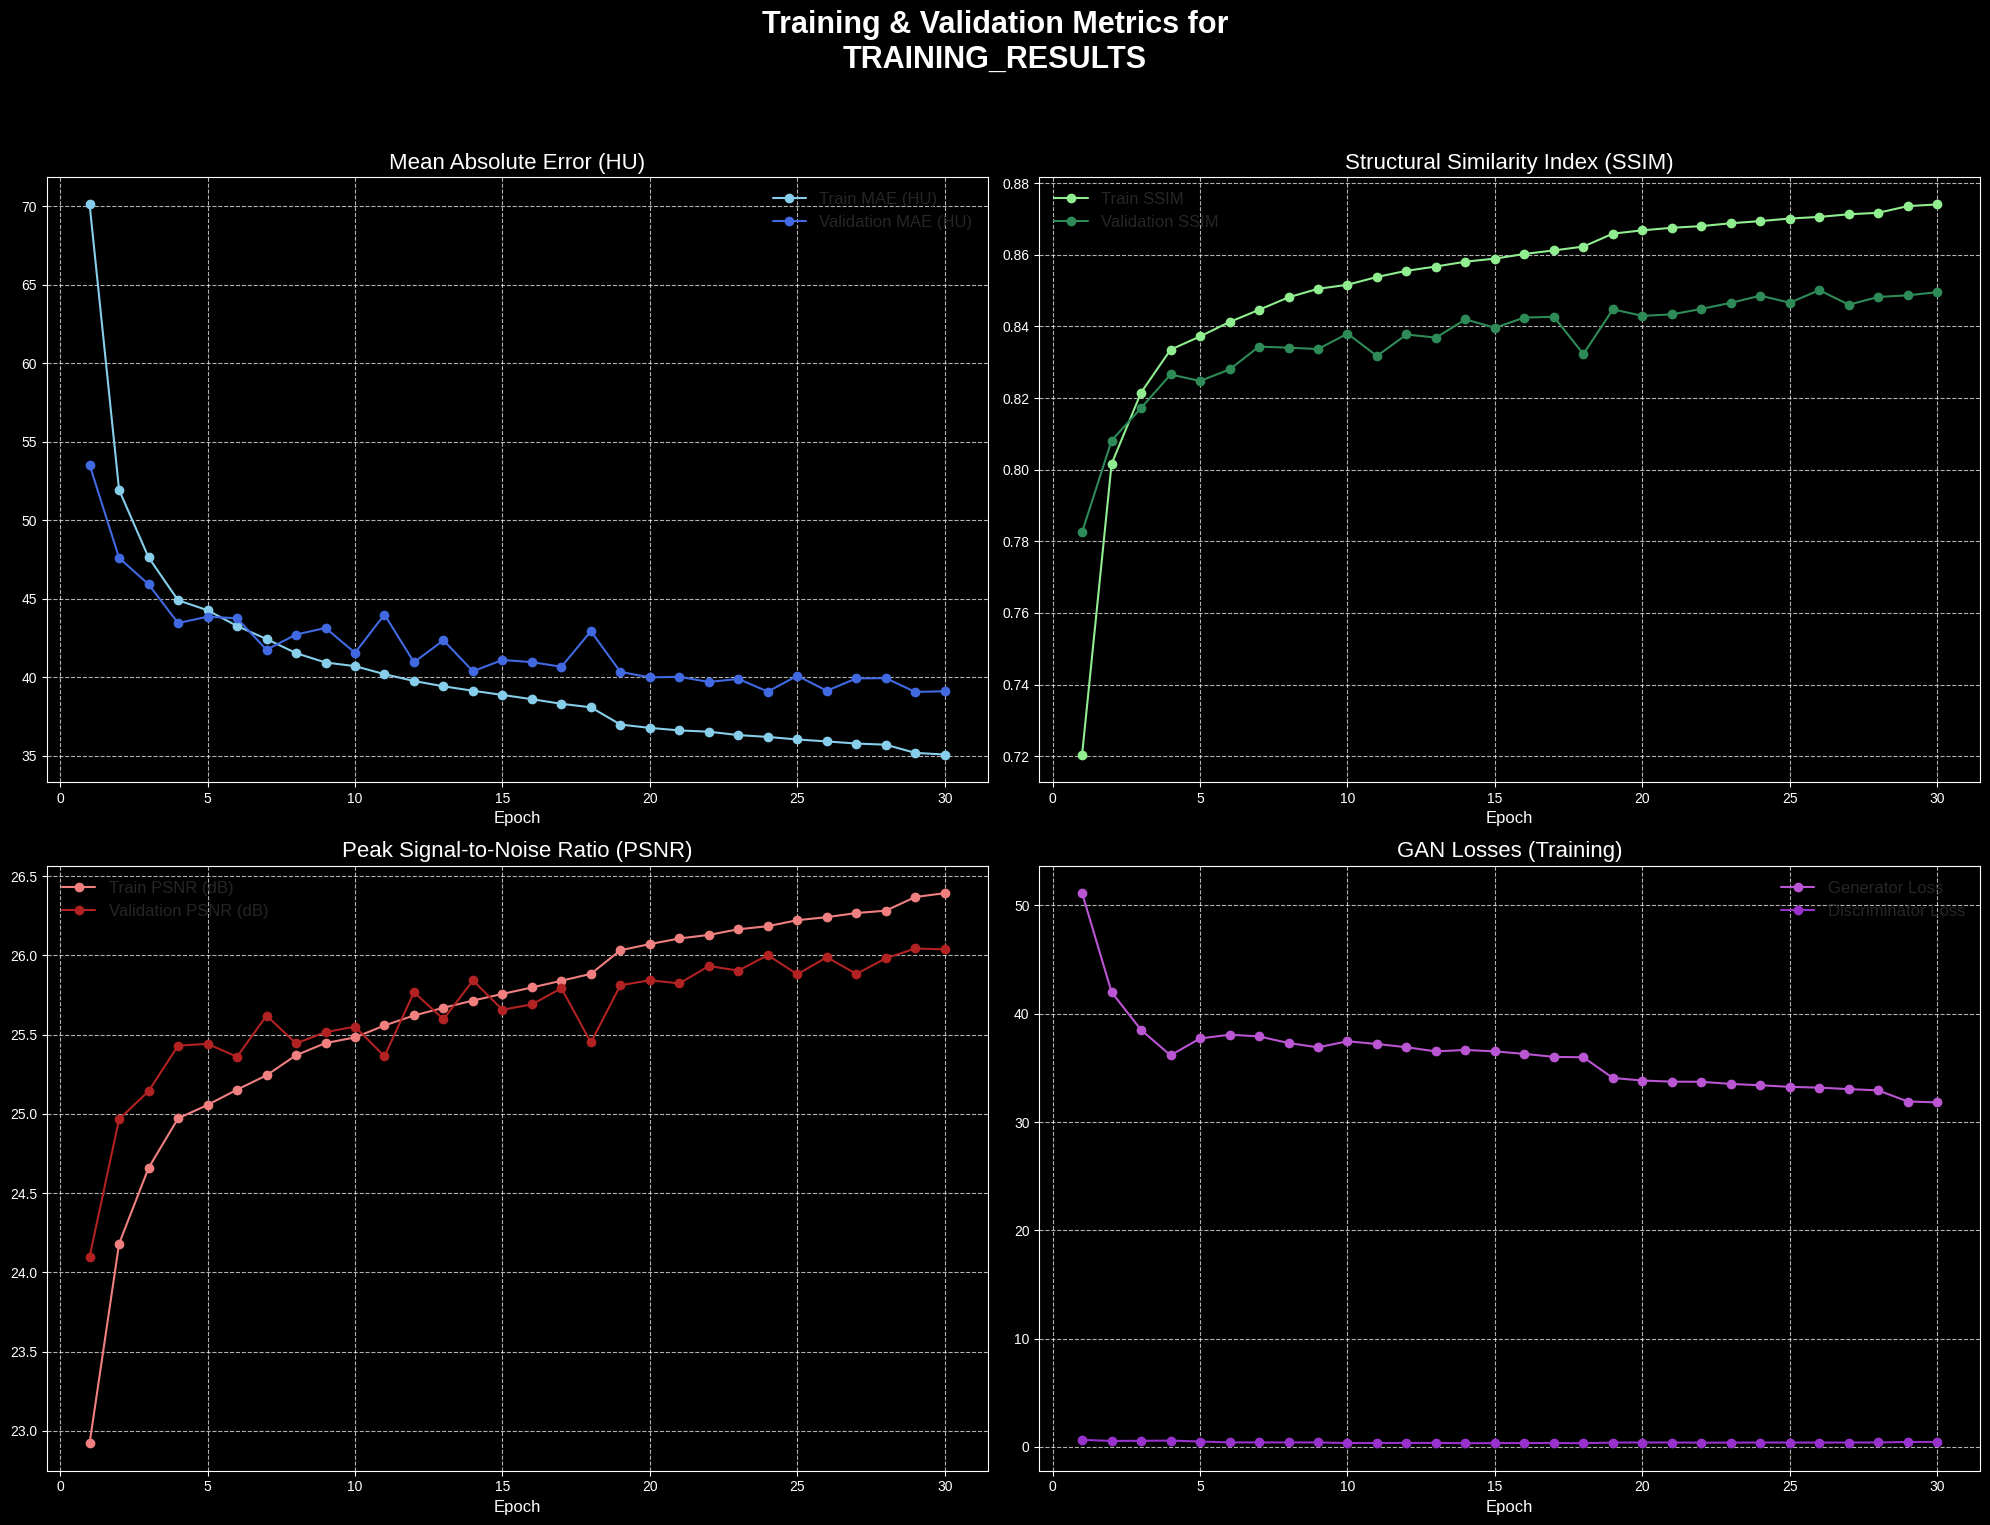

In [18]:
import json
import matplotlib.pyplot as plt
import os
from pathlib import Path

# --- 1. Configuration (Automatically finds the latest experiment) ---
base_results_dir = Path("./training_results")
latest_experiment_dir = None
experiment_name = "N/A"

try:
    all_experiments = [d for d in base_results_dir.iterdir() if d.is_dir()]
    if all_experiments:
        latest_experiment_dir = sorted(all_experiments)[-1]
        experiment_name = latest_experiment_dir.name
        print(f"✅ Automatically found latest experiment: {experiment_name}")
except FileNotFoundError:
    print(f"Error: Base results directory not found at '{base_results_dir}'.")

if latest_experiment_dir is None:
    print("Error: No experiment folders found. Please run the training script first.")
    exit()
else:
    results_dir = latest_experiment_dir
    history_path = results_dir / "training_history.json"

# --- 2. Plotting Function ---
def plot_training_history(history_path, save_dir, experiment_title):
    """Loads and plots the training and validation history from a JSON file."""
    try:
        with open(history_path, 'r') as f:
            history = json.load(f)
    except FileNotFoundError:
        print(f"Error: History file not found at {history_path}")
        return
        
    train_hist = history.get('train', [])
    val_hist = history.get('val', [])
    
    if not train_hist or not val_hist:
        print("Error: History file is missing 'train' or 'val' data.")
        return

    # CORRECTED: If 'epoch' key is missing, generate epoch numbers manually
    if 'epoch' in train_hist[0]:
        epochs = [item['epoch'] for item in train_hist]
    else:
        print("Warning: 'epoch' key not found in history. Generating epoch numbers sequentially.")
        epochs = range(1, len(train_hist) + 1)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle(f'Training & Validation Metrics for\n{experiment_title}', fontsize=22, weight='bold')
    plt.style.use('seaborn-v0_8-whitegrid')

    # MAE (HU) Plot
    ax = axes[0, 0]
    ax.plot(epochs, [item.get('MAE') for item in train_hist], 'o-', color='skyblue', label='Train MAE (HU)')
    ax.plot(epochs, [item.get('MAE') for item in val_hist], 'o-', color='royalblue', label='Validation MAE (HU)')
    ax.set_title('Mean Absolute Error (HU)', fontsize=16)
    
    # SSIM Plot
    ax = axes[0, 1]
    ax.plot(epochs, [item.get('SSIM') for item in train_hist], 'o-', color='lightgreen', label='Train SSIM')
    ax.plot(epochs, [item.get('SSIM') for item in val_hist], 'o-', color='seagreen', label='Validation SSIM')
    ax.set_title('Structural Similarity Index (SSIM)', fontsize=16)

    # PSNR Plot
    ax = axes[1, 0]
    ax.plot(epochs, [item.get('PSNR') for item in train_hist], 'o-', color='lightcoral', label='Train PSNR (dB)')
    ax.plot(epochs, [item.get('PSNR') for item in val_hist], 'o-', color='firebrick', label='Validation PSNR (dB)')
    ax.set_title('Peak Signal-to-Noise Ratio (PSNR)', fontsize=16)

    # GAN Losses Plot
    ax = axes[1, 1]
    ax.plot(epochs, [item.get('G_loss') for item in train_hist], 'o-', color='mediumorchid', label='Generator Loss')
    ax.plot(epochs, [item.get('D_loss') for item in train_hist], 'o-', color='darkorchid', label='Discriminator Loss')
    ax.set_title('GAN Losses (Training)', fontsize=16)

    # Universal styling
    for ax_row in axes:
        for ax in ax_row: 
            ax.set_xlabel('Epoch', fontsize=12)
            ax.grid(True, linestyle='--', alpha=0.7)
            ax.legend(fontsize=12)

    plot_path = save_dir / "metrics_plot.png"
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(plot_path, dpi=150)
    print(f"📈 Plot saved to {plot_path}")
    plt.show()

# --- 3. Execution ---
if __name__ == '__main__':
    if latest_experiment_dir and history_path.exists():
        plot_training_history(history_path, results_dir, experiment_name)
    else:
        print("Could not generate plot. Please check the paths and ensure training is complete.")



In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm
import numpy as np
import os
import matplotlib.pyplot as plt
import json
from pathlib import Path

# --- 1. Configuration (Automatically finds the latest experiment) ---
# This section makes the script robust by finding the latest results folder
# so you don't have to manually update the name each time.
base_results_dir = Path("./training_results")
latest_experiment_dir = None
experiment_name = "N/A"

try:
    # Find all subdirectories (which are our experiment folders)
    all_experiments = [d for d in base_results_dir.iterdir() if d.is_dir()]
    if all_experiments:
        # Sort them by name (timestamps) and get the latest one
        latest_experiment_dir = sorted(all_experiments)[-1]
        experiment_name = latest_experiment_dir.name
        print(f"✅ Automatically found latest experiment: {experiment_name}")
except FileNotFoundError:
    print(f"Error: Base results directory not found at '{base_results_dir}'.")

if latest_experiment_dir is None:
    print("Error: No experiment folders found. Please run the training script first.")
    # Use a placeholder to prevent crashing, but the script will exit gracefully later.
    latest_experiment_dir = base_results_dir / "default"

# Define all paths
results_dir = latest_experiment_dir
checkpoint_path = results_dir / "checkpoints" / "best_model_G.pth"
root_data_path = Path("/kaggle/working/paired_slices_split_npy")

def visualize_test_results(model, loader, device, num_samples, save_dir):
    """Generates and saves visual comparisons of model predictions on test data."""
    model.eval()
    with torch.no_grad():
        x, y = next(iter(loader))
        fake_y = model(x.to(device))
        num_samples = min(num_samples, x.size(0))
        for i in range(num_samples):
            fig, ax = plt.subplots(1, 3, figsize=(18, 6))
            fig.suptitle(f'Test Sample #{i+1}', fontsize=16, weight='bold')
            
            # Un-normalize for better visualization if needed, but grayscale often works well
            mri_img = x[i].squeeze().cpu().numpy()
            ct_img = y[i].squeeze().cpu().numpy()
            pred_img = fake_y[i].squeeze().cpu().numpy()
            
            ax[0].imshow(mri_img, cmap='gray'); ax[0].set_title("Input MRI"); ax[0].axis('off')
            ax[1].imshow(ct_img, cmap='gray'); ax[1].set_title("Ground Truth CT"); ax[1].axis('off')
            ax[2].imshow(pred_img, cmap='gray'); ax[2].set_title("Predicted CT"); ax[2].axis('off')
            
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.savefig(save_dir / f"test_sample_{i+1}.png", dpi=120)
            plt.close() # Close plot to avoid displaying it in the notebook

# --- 3. Main Evaluation Function ---
def evaluate_on_test_set():
    if not latest_experiment_dir or not checkpoint_path.exists():
        print(f"Error: Could not find model checkpoint at {checkpoint_path}. Please run training first.")
        return

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load the best model from the training run
    model = UNetGenerator().to(device)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    # Create the test dataset and loader
    test_transform = transforms.Resize((256, 256), antialias=True)
    test_dataset = PairedSlicesDataset(root_data_path, "test", transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=True) # Shuffle for random visualization samples
    
    print("\n🔬 Running evaluation on the test set...")
    all_metrics = {'ssim': [], 'psnr': [], 'mae': []}
    l1_loss_fn = nn.L1Loss()
    
    with torch.no_grad():
        for x, y in tqdm(test_loader, desc="Testing"):
            x, y = x.to(device), y.to(device)
            ssim_val, psnr_val, mae_val = compute_metrics(model(x), y, l1_loss_fn)
            all_metrics['ssim'].append(ssim_val)
            all_metrics['psnr'].append(psnr_val)
            all_metrics['mae'].append(mae_val)

    # --- Print and Save Final Results ---
    print("\n" + "="*50)
    print("📊 FINAL TEST SET RESULTS 📊")
    print("="*50)
    summary = {}
    for name, values in all_metrics.items():
        mean, std = np.mean(values), np.std(values)
        summary[name] = {'mean': mean, 'std': std}
        print(f"  - {name.upper():<5} | Mean: {mean:.4f} ± {std:.4f}")
    
    with open(results_dir / "test_set_results.json", 'w') as f: json.dump(summary, f, indent=4)
    print("\n✅ Evaluation summary saved.")
    
    # --- Generate Visualizations ---
    print("🖼️ Generating test set visualizations...")
    visualize_test_results(model, test_loader, device, num_samples=5, save_dir=results_dir)
    print(f"   Visualizations saved in: {results_dir}")

if __name__ == '__main__':
    evaluate_on_test_set()



✅ Automatically found latest experiment: TRAINING_RESULTS

🔬 Running evaluation on the test set...


Testing: 100%|██████████| 195/195 [00:14<00:00, 13.77it/s]



📊 FINAL TEST SET RESULTS 📊
  - SSIM  | Mean: 0.8680 ± 0.0155
  - PSNR  | Mean: 26.0165 ± 0.7180
  - MAE   | Mean: 34.7535 ± 3.5503

✅ Evaluation summary saved.
🖼️ Generating test set visualizations...
   Visualizations saved in: training_results/TRAINING_RESULTS
